# Бенчмарк на синтетических данных generator.py

**Параметры:** V ∈ {15, 50} признаков, K ∈ {7, 15, 21} кластеров, α ∈ {0.25, 0.50, 0.75} сжатия, N=1000 объектов

In [24]:
import sys, time, warnings
from pathlib import Path
from itertools import product as iproduct
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (adjusted_rand_score, adjusted_mutual_info_score,
    normalized_mutual_info_score, fowlkes_mallows_score,
    silhouette_score, calinski_harabasz_score, davies_bouldin_score)
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

from algorithms import DBSCANWrapper, HDBSCANWrapper, DPCWrapper, RDDACWrapper, CKDPCWrapper

In [25]:
EXPERIMENT_DIR = Path('../synthetic_datasets/experiment')
N_REPS = 10

def parse_combo(name):
    parts = {}
    for p in name.split('_'):
        if p.startswith('V='): parts['V']     = int(p[2:])
        if p.startswith('K='): parts['K']     = int(p[2:])
        if p.startswith('alpha='): parts['alpha'] = float(p[6:])
    return parts

combos = sorted(
    [d for d in EXPERIMENT_DIR.iterdir() if d.is_dir()],
    key=lambda p: p.name
)

rows = []
for c in combos:
    p = parse_combo(c.name)
    n_reps = len(list(c.glob('rep*_X.npy')))
    rows.append({**p, 'combo': c.name, 'reps_available': n_reps})

df_combos = pd.DataFrame(rows)
display(df_combos)

,V,K,alpha,combo,reps_available
0,15,7,0.25,V=15_K= 7_alpha=0.25,30
1,15,7,0.50,V=15_K= 7_alpha=0.50,30
2,15,7,0.75,V=15_K= 7_alpha=0.75,30
3,15,15,0.25,V=15_K=15_alpha=0.25,30
4,15,15,0.50,V=15_K=15_alpha=0.50,30
5,15,15,0.75,V=15_K=15_alpha=0.75,30
6,15,21,0.25,V=15_K=21_alpha=0.25,30
7,15,21,0.50,V=15_K=21_alpha=0.50,30
8,15,21,0.75,V=15_K=21_alpha=0.75,30
9,50,7,0.25,V=50_K= 7_alpha=0.25,30


In [26]:
ALG_NAMES = ['DBSCAN', 'HDBSCAN', 'DPC', 'RD-DAC', 'CKDPC']
ALG_CLASSES = {
    'DBSCAN':  DBSCANWrapper,
    'HDBSCAN': HDBSCANWrapper,
    'DPC':     DPCWrapper,
    'RD-DAC':  RDDACWrapper,
    'CKDPC':   CKDPCWrapper,
}


def compute_metrics(X, labels, y_true):
    labels  = np.asarray(labels, dtype=int)
    y_true  = np.asarray(y_true, dtype=int)
    mask_nn = labels != -1
    k_found   = len(set(labels[mask_nn].tolist())) if mask_nn.any() else 0
    noise_pct = float((~mask_nn).sum()) / len(labels) * 100

    if k_found >= 2:
        ari = float(adjusted_rand_score(y_true, labels))
        ami = float(adjusted_mutual_info_score(y_true, labels))
        nmi = float(normalized_mutual_info_score(y_true, labels))
        fmi = float(fowlkes_mallows_score(y_true, labels))
    elif k_found == 1:
        ari = ami = nmi = fmi = 0.0
    else:
        ari = ami = nmi = fmi = float('nan')

    X_sub, l_sub = X[mask_nn], labels[mask_nn]
    if mask_nn.sum() >= 2 and len(np.unique(l_sub)) >= 2:
        try:    sc  = float(silhouette_score(X_sub, l_sub))
        except: sc  = float('nan')
        try:    dbi = float(davies_bouldin_score(X_sub, l_sub))
        except: dbi = float('nan')
    else:
        sc = dbi = float('nan')

    return dict(k_found=k_found, noise_pct=noise_pct,
                ARI=ari, AMI=ami, NMI=nmi, FMI=fmi, SC=sc, DBI=dbi)


def _arange(a, b, step, dec=4):
    return [round(float(v), dec) for v in np.arange(a, b + step*0.5, step)]


def _eps_grid(X, n_steps=10):
    X_s = MinMaxScaler().fit_transform(X)
    nbrs = NearestNeighbors(n_neighbors=5).fit(X_s)
    d, _ = nbrs.kneighbors(X_s)
    d_med = float(np.median(d[:, 2]))
    d_90  = float(np.percentile(d[:, 2], 90))
    lo = max(0.01, round(d_med * 0.3, 4))
    hi = round(d_90 * 3.0, 4)
    step = max(0.005, round((hi - lo) / n_steps, 4))
    return _arange(lo, hi, step)


def get_param_grid(alg_name, X):
    n = X.shape[0]
    if alg_name == 'DBSCAN':
        return {
            'eps':         _eps_grid(X, n_steps=12),
            'min_samples': list(range(1, 21)),
        }
    if alg_name == 'HDBSCAN':
        return {
            'min_cluster_size': list(range(2, 61, 3)),
            'min_samples':      list(range(1, 11)),
        }
    if alg_name == 'DPC':
        return {
            'percent': _arange(0.5, 20.0, 0.5),
        }
    if alg_name == 'RD-DAC':
        return {
            'k': list(range(2, 36)),
        }
    if alg_name == 'CKDPC':
        return {
            'alpha':   _arange(0.05, 10.0, 0.50),
            'percent': _arange(1.0, 20.0, 2.0),
        }
    return {}


def grid_search_best_params(alg_name, X, y_true):
    alg_class = ALG_CLASSES[alg_name]
    pgrid = get_param_grid(alg_name, X)
    keys = list(pgrid.keys())
    combos_g = list(iproduct(*[pgrid[k] for k in keys])) if keys else [()]
    best_ari, best_params = -2.0, {}
    for combo in combos_g:
        params = dict(zip(keys, combo))
        try:
            lbl  = np.asarray(alg_class(**params).fit_predict(X), dtype=int)
            mets = compute_metrics(X, lbl, y_true)
            ari  = mets['ARI'] if mets['ARI'] == mets['ARI'] else -1.0
            if ari > best_ari:
                best_ari = ari; best_params = params
        except Exception:
            pass
    return best_params

In [27]:
ALL_RESULTS = {}

for combo_dir in combos:
    cname = combo_dir.name
    p = parse_combo(cname)
    V, K, alpha = p['V'], p['K'], p['alpha']

    rep01_X  = np.load(combo_dir / 'rep001_X.npy')
    rep01_rf = np.load(combo_dir / 'rep001_rf.npy')
    y01 = rep01_rf.astype(int) - 1

    t0 = time.time()
    best_params_per_alg = {}
    for alg_name in ALG_NAMES:
        best_params_per_alg[alg_name] = grid_search_best_params(alg_name, rep01_X, y01)

    rep_files = sorted(combo_dir.glob('rep*_X.npy'))[:N_REPS]
    per_rep = {a: [] for a in ALG_NAMES}

    for xf in rep_files:
        rep_id = xf.stem.replace('_X', '')
        X   = np.load(xf)
        rf  = np.load(combo_dir / f'{rep_id}_rf.npy')
        y   = rf.astype(int) - 1
        for alg_name in ALG_NAMES:
            params = best_params_per_alg[alg_name]
            try:
                lbl  = np.asarray(ALG_CLASSES[alg_name](**params).fit_predict(X), dtype=int)
                mets = compute_metrics(X, lbl, y)
            except Exception:
                mets = dict(k_found=0, noise_pct=100.0, ARI=float('nan'),
                            AMI=float('nan'), NMI=float('nan'), FMI=float('nan'),
                            SC=float('nan'), DBI=float('nan'))
            per_rep[alg_name].append(mets)

    ALL_RESULTS[cname] = {
        'V': V, 'K': K, 'alpha': alpha,
        'per_rep': per_rep,
        'best_params': best_params_per_alg,
        'rep01_X': rep01_X, 'rep01_y': y01,
    }
    elapsed = time.time() - t0
    print(f'{cname:<30}')

V=15_K= 7_alpha=0.25          
V=15_K= 7_alpha=0.50          
V=15_K= 7_alpha=0.75          
V=15_K=15_alpha=0.25          
V=15_K=15_alpha=0.50          
V=15_K=15_alpha=0.75          
V=15_K=21_alpha=0.25          
V=15_K=21_alpha=0.50          
V=15_K=21_alpha=0.75          
V=50_K= 7_alpha=0.25          
V=50_K= 7_alpha=0.50          
V=50_K= 7_alpha=0.75          
V=50_K=15_alpha=0.25          
V=50_K=15_alpha=0.50          
V=50_K=15_alpha=0.75          
V=50_K=21_alpha=0.25          
V=50_K=21_alpha=0.50          
V=50_K=21_alpha=0.75          


In [28]:
def _safe_mean(vals, key):
    v = [x[key] for x in vals if isinstance(x[key], (int, float)) and x[key]==x[key]]
    return round(float(np.mean(v)), 4) if v else float('nan')

METS = ['ARI', 'AMI', 'NMI', 'FMI', 'SC', 'DBI', 'k_found', 'noise_pct']

rows_avg = []
for cname, res in ALL_RESULTS.items():
    for alg in ALG_NAMES:
        vals = res['per_rep'][alg]
        row = {'combo': cname, 'V': res['V'], 'K': res['K'], 'alpha': res['alpha'],
               'Algorithm': alg}
        for m in METS:
            row[m] = _safe_mean(vals, m)
        row['best_params'] = str(res['best_params'][alg])
        rows_avg.append(row)

df_avg = pd.DataFrame(rows_avg)

SHOW_COLS = ['Algorithm', 'ARI', 'AMI', 'NMI', 'FMI', 'SC', 'DBI', 'k_found', 'noise_pct', 'best_params']
FMT = {'ARI':'{:.4f}','AMI':'{:.4f}','NMI':'{:.4f}','FMI':'{:.4f}',
       'SC':'{:.4f}','DBI':'{:.4f}','k_found':'{:.1f}','noise_pct':'{:.1f}'}

for cname in list(ALL_RESULTS.keys()):
    sub = df_avg[df_avg['combo'] == cname][SHOW_COLS].set_index('Algorithm')
    print(f'\n{cname}')
    display(sub.style.format(FMT))


V=15_K= 7_alpha=0.25


,ARI,AMI,NMI,FMI,SC,DBI,k_found,noise_pct,best_params
Algorithm,,,,,,,,,
DBSCAN,1.0000,1.0000,1.0000,1.0000,0.7870,0.3071,7.0,0.0,"{'eps': 0.3429, 'min_samples': 1}"
HDBSCAN,1.0000,1.0000,1.0000,1.0000,0.7870,0.3071,7.0,0.0,"{'min_cluster_size': 2, 'min_samples': 1}"
DPC,0.9836,0.9889,0.9890,0.9860,0.6840,0.9766,8.0,0.0,{'percent': 15.0}
RD-DAC,0.9712,0.9815,0.9817,0.9756,0.6803,1.2527,8.0,0.0,{'k': 7}
CKDPC,0.8921,0.9004,0.9015,0.9081,0.7664,0.3599,7.2,8.0,"{'alpha': 0.25, 'percent': 13.0}"



V=15_K= 7_alpha=0.50


,ARI,AMI,NMI,FMI,SC,DBI,k_found,noise_pct,best_params
Algorithm,,,,,,,,,
DBSCAN,0.9996,0.9993,0.9993,0.9996,0.6943,0.4472,7.0,0.0,"{'eps': 0.3611, 'min_samples': 1}"
HDBSCAN,1.0000,1.0000,1.0000,1.0000,0.6942,0.4473,7.0,0.0,"{'min_cluster_size': 2, 'min_samples': 1}"
DPC,0.9872,0.9915,0.9916,0.9891,0.6042,0.8667,8.0,0.0,{'percent': 14.5}
RD-DAC,0.9753,0.9841,0.9843,0.9790,0.5979,1.2006,8.0,0.0,{'k': 2}
CKDPC,0.8931,0.8990,0.9001,0.9089,0.6547,0.4880,7.5,7.8,"{'alpha': 0.05, 'percent': 15.0}"



V=15_K= 7_alpha=0.75


...

,ARI,AMI,NMI,FMI,SC,DBI,k_found,noise_pct,best_params
Algorithm,,,,,,,,,
DBSCAN,1.0000,1.0000,1.0000,1.0000,0.7956,0.2923,21.0,0.0,"{'eps': 0.4771, 'min_samples': 1}"
HDBSCAN,1.0000,1.0000,1.0000,1.0000,0.7956,0.2923,21.0,0.0,"{'min_cluster_size': 2, 'min_samples': 1}"
DPC,0.9979,0.9986,0.9987,0.9980,0.7601,0.3832,22.0,0.0,{'percent': 5.5}
RD-DAC,0.9919,0.9961,0.9964,0.9923,0.7577,0.5802,22.0,0.0,{'k': 2}
CKDPC,0.8807,0.9271,0.9328,0.8864,0.7772,0.3205,21.6,7.1,"{'alpha': 0.25, 'percent': 7.0}"



V=50_K=21_alpha=0.50


,ARI,AMI,NMI,FMI,SC,DBI,k_found,noise_pct,best_params
Algorithm,,,,,,,,,
DBSCAN,1.0000,1.0000,1.0000,1.0000,0.7015,0.4352,21.0,0.0,"{'eps': 0.6417, 'min_samples': 1}"
HDBSCAN,1.0000,1.0000,1.0000,1.0000,0.7015,0.4352,21.0,0.0,"{'min_cluster_size': 2, 'min_samples': 1}"
DPC,0.9961,0.9978,0.9979,0.9963,0.6723,0.5850,22.0,0.0,{'percent': 5.0}
RD-DAC,0.9900,0.9953,0.9956,0.9905,0.6689,0.7576,22.0,0.0,{'k': 2}
CKDPC,0.8774,0.9246,0.9305,0.8832,0.6943,0.4526,21.4,7.3,"{'alpha': 0.15, 'percent': 7.0}"



V=50_K=21_alpha=0.75


,ARI,AMI,NMI,FMI,SC,DBI,k_found,noise_pct,best_params
Algorithm,,,,,,,,,
DBSCAN,1.0000,1.0000,1.0000,1.0000,0.4591,0.8796,21.0,0.0,"{'eps': 0.9855, 'min_samples': 1}"
HDBSCAN,1.0000,1.0000,1.0000,1.0000,0.4591,0.8796,21.0,0.0,"{'min_cluster_size': 2, 'min_samples': 1}"
DPC,0.0571,0.2830,0.2872,0.2732,0.0604,3.3057,2.0,0.0,{'percent': 0.5}
RD-DAC,0.5998,0.6525,0.6550,0.6874,0.2934,1.4472,14.0,0.0,{'k': 4}
CKDPC,0.0542,0.1939,0.2025,0.2323,0.0515,4.4844,2.0,7.3,"{'alpha': 0.55, 'percent': 5.0}"


In [29]:
for V_val in [15, 50]:
    print(f'\nV={V_val} Средний ARI (по {N_REPS} rep) ')
    sub = df_avg[df_avg['V'] == V_val]
    pivot = sub.pivot_table(index=['K','alpha'], columns='Algorithm', values='ARI', aggfunc='mean')
    pivot = pivot[ALG_NAMES]
    display(pivot.style
            .format('{:.4f}', na_rep='-')
            .background_gradient(cmap='RdYlGn', axis=None, vmin=0, vmax=1))


V=15 Средний ARI (по 10 rep) 



V=50 Средний ARI (по 10 rep) 


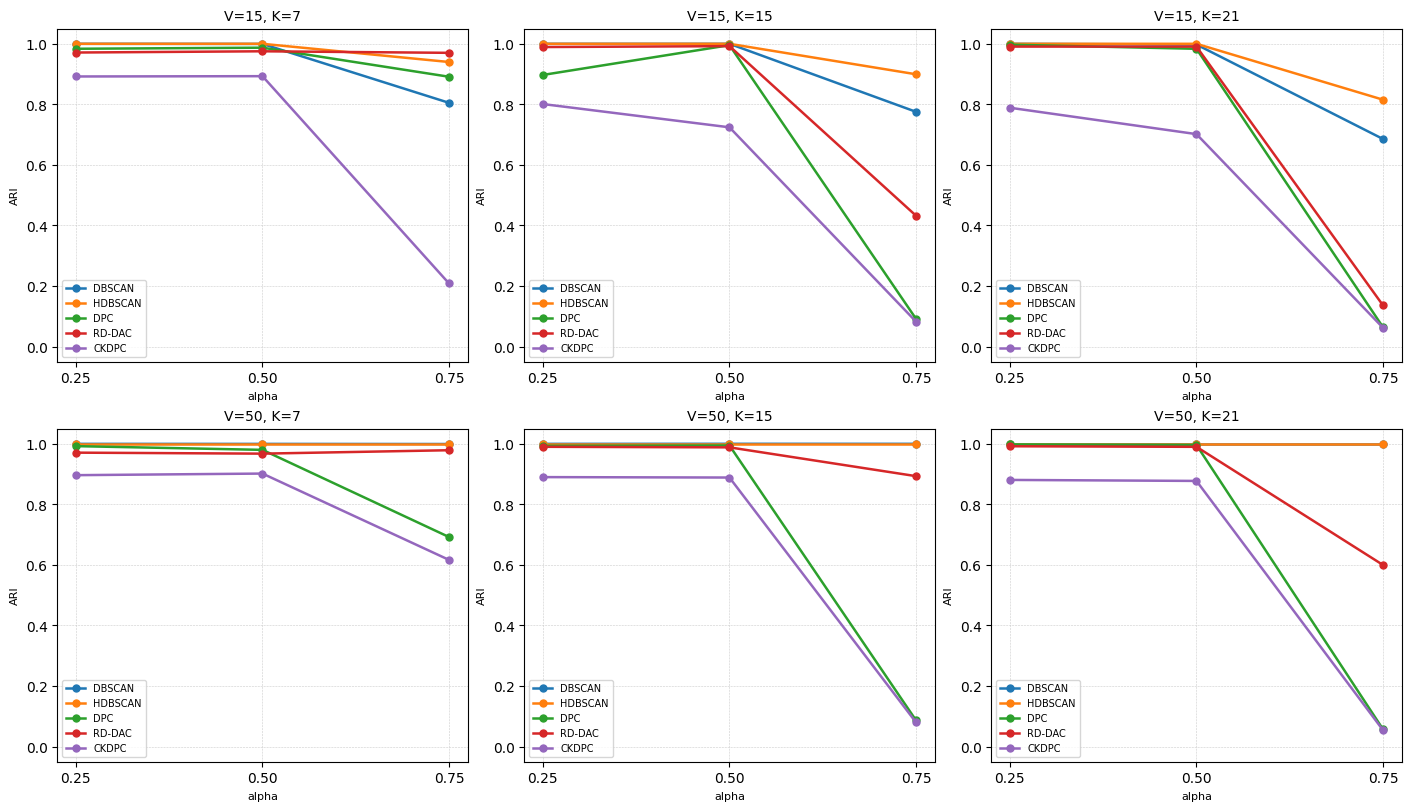

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
colors = plt.get_cmap('tab10')

for row_i, V_val in enumerate([15, 50]):
    for col_i, K_val in enumerate([7, 15, 21]):
        ax = axes[row_i, col_i]
        sub = df_avg[(df_avg['V'] == V_val) & (df_avg['K'] == K_val)]
        for j, alg in enumerate(ALG_NAMES):
            s_alg = sub[sub['Algorithm'] == alg].sort_values('alpha')
            ax.plot(s_alg['alpha'], s_alg['ARI'], marker='o',
                    label=alg, color=colors(j), linewidth=1.8, markersize=5)
        ax.set_title(f'V={V_val}, K={K_val}', fontsize=10)
        ax.set_xlabel('alpha', fontsize=8)
        ax.set_ylabel('ARI', fontsize=8)
        ax.set_ylim(-0.05, 1.05)
        ax.set_xticks([0.25, 0.50, 0.75])
        ax.grid(True, linewidth=0.4, linestyle='--', color='#cccccc')
        ax.legend(fontsize=7)

import os; os.makedirs('../results/generator_figures', exist_ok=True)
fig.savefig('../results/generator_figures/ari_vs_alpha.png', dpi=150, bbox_inches='tight')
plt.show()

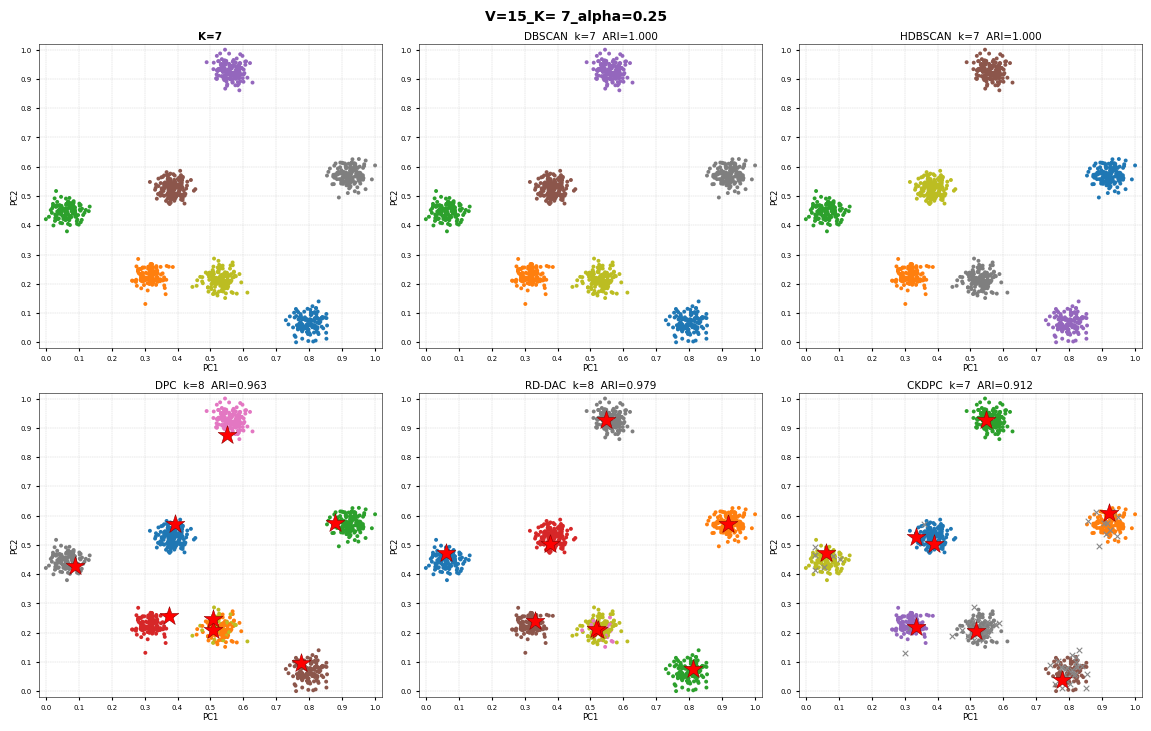

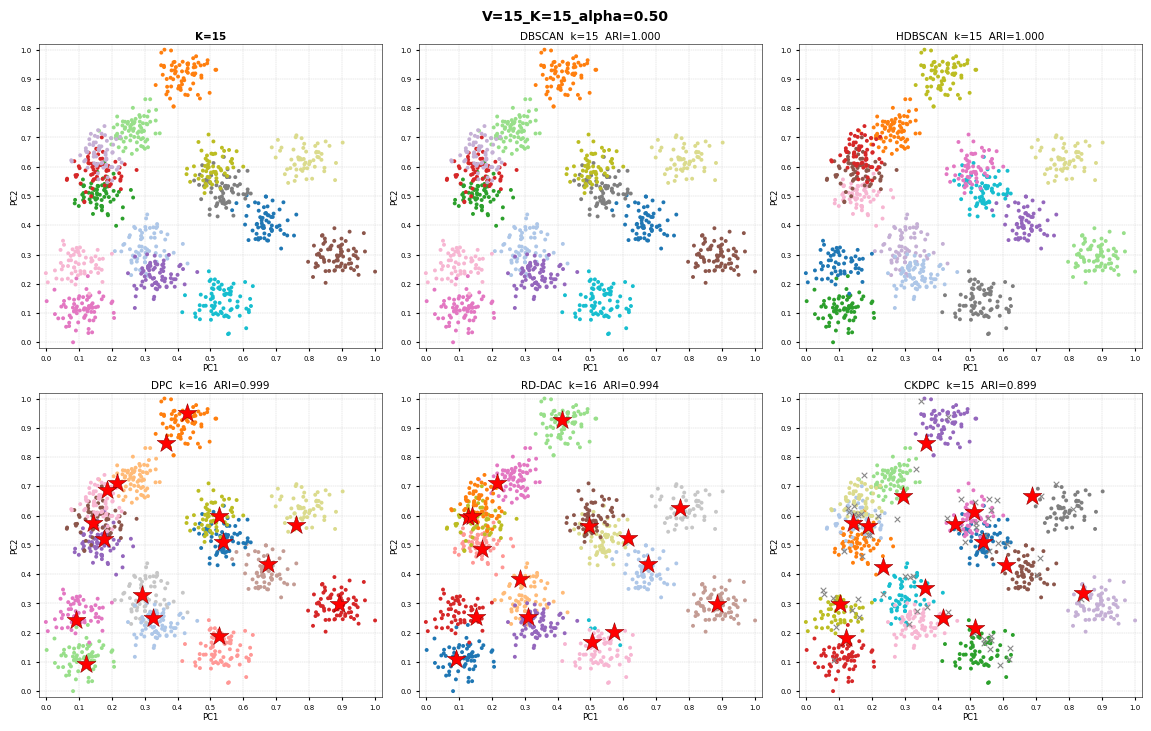

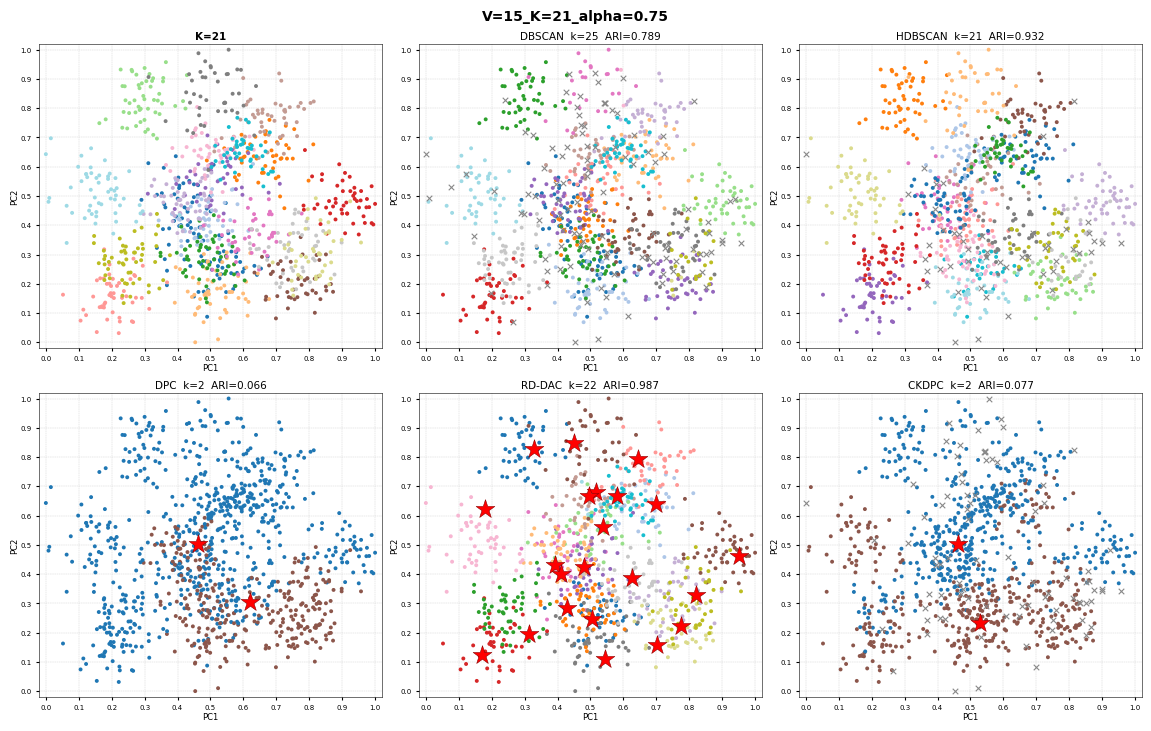

In [31]:
TICKS_01 = [round(i*0.1, 1) for i in range(11)]
SHOW_COMBOS = [
    'V=15_K= 7_alpha=0.25',
    'V=15_K=15_alpha=0.50',
    'V=15_K=21_alpha=0.75',
]


def _cluster_colors(labels):
    ids = sorted(set(labels.tolist()))
    clust_ids = [i for i in ids if i != -1]
    n_c = len(clust_ids)
    cmap = plt.get_cmap('tab10') if n_c <= 10 else plt.get_cmap('tab20')
    return {c: cmap(j / max(n_c, 1)) for j, c in enumerate(clust_ids)}


def _plot_ax(ax, X_pca, labels, alg_obj=None, title=''):
    cm = _cluster_colors(labels)
    mn, mc = labels == -1, labels != -1
    s = max(8, min(30, int(1500 / len(labels))))
    if mc.any():
        cols = np.array([cm[l] for l in labels[mc]])
        ax.scatter(X_pca[mc, 0], X_pca[mc, 1], c=cols, s=s, linewidths=0, zorder=2)
    if mn.any():
        ax.scatter(X_pca[mn, 0], X_pca[mn, 1],
                   color='#888888', marker='x', s=s+8, linewidths=0.8, zorder=3)
    if alg_obj is not None:
        cens = getattr(alg_obj, 'centers_', None)
        if cens is not None and len(cens):
            ax.scatter(X_pca[cens, 0], X_pca[cens, 1],
                       marker='*', s=200, c='red', zorder=5,
                       linewidths=0.4, edgecolors='darkred')
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    ax.set_xticks(TICKS_01); ax.set_yticks(TICKS_01)
    ax.tick_params(labelsize=5, length=2)
    ax.grid(True, color='#cccccc', linewidth=0.3, linestyle='--', zorder=0)
    for sp in ax.spines.values(): sp.set_linewidth(0.4)
    ax.set_title(title, fontsize=7.5, pad=3)
    ax.set_xlabel('PC1', fontsize=6, labelpad=1)
    ax.set_ylabel('PC2', fontsize=6, labelpad=1)


for cname in SHOW_COMBOS:
    if cname not in ALL_RESULTS:
        print(f'Combo {cname!r} not found, skip'); continue
    res = ALL_RESULTS[cname]
    X_raw, y_true = res['rep01_X'], res['rep01_y']

    pca = PCA(n_components=2, random_state=0)
    X_s   = MinMaxScaler().fit_transform(X_raw)
    X_pca = MinMaxScaler().fit_transform(pca.fit_transform(X_s))
    ev    = pca.explained_variance_ratio_

    n_cols = 3
    n_items = len(ALG_NAMES) + 1
    n_rows = int(np.ceil(n_items / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(n_cols*3.8, n_rows*3.6),
                              constrained_layout=True)
    axes = axes.ravel()

    _plot_ax(axes[0], X_pca, y_true,
             title=f'K={res["K"]}')
    axes[0].title.set_fontweight('bold')

    for idx, alg_name in enumerate(ALG_NAMES):
        params = res['best_params'][alg_name]
        try:
            alg_obj = ALG_CLASSES[alg_name](**params)
            lbl = np.asarray(alg_obj.fit_predict(X_raw), dtype=int)
            mets = compute_metrics(X_raw, lbl, y_true)
        except Exception:
            lbl = np.zeros(len(y_true), dtype=int); alg_obj = None
            mets = dict(ARI=float('nan'), k_found=0)
        ari_s = f'{mets["ARI"]:.3f}' if mets["ARI"]==mets["ARI"] else '-'
        _plot_ax(axes[idx+1], X_pca, lbl, alg_obj=alg_obj,
                 title=f'{alg_name}  k={mets["k_found"]}  ARI={ari_s}')

    for ax in axes[n_items:]: ax.set_visible(False)

    fig.suptitle(f'{cname}', fontsize=10, fontweight='bold')
    fig.savefig(f'../results/generator_figures/{cname}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [32]:
print('\nCредний ARI по всем комбо')
pivot_full = df_avg.pivot_table(
    index=['V','K','alpha'], columns='Algorithm', values='ARI', aggfunc='mean')
pivot_full = pivot_full[ALG_NAMES]
display(pivot_full.style
        .format('{:.4f}', na_rep='-')
        .background_gradient(cmap='RdYlGn', axis=None, vmin=0, vmax=1))


Cредний ARI по всем комбо
